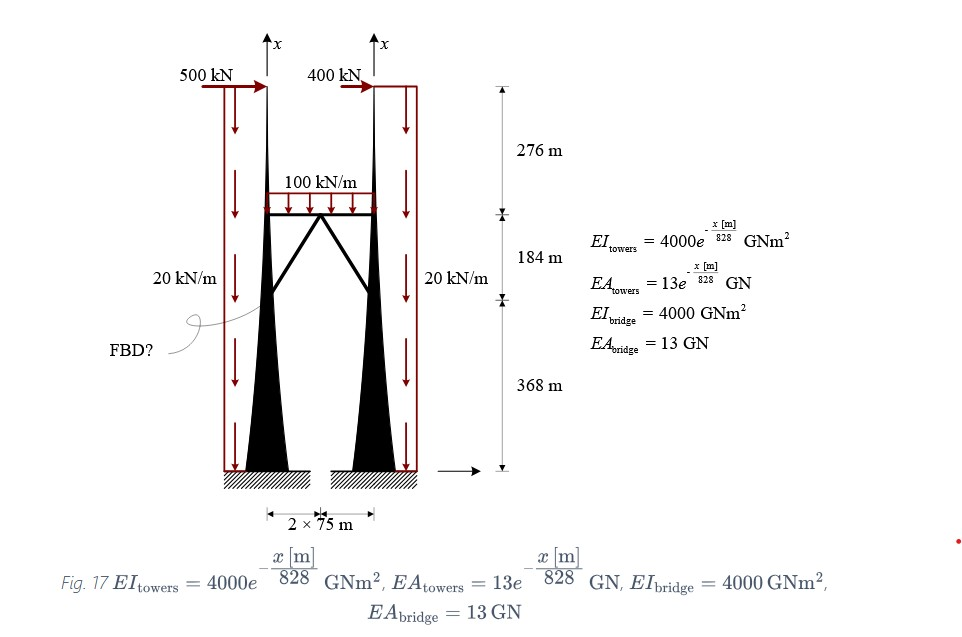

In [9]:
from IPython.display import Image, display
display(Image(filename='Screenshot 2026-04-17 100516.jpg'))

In [10]:
import numpy as np
import matrixmethod as mm
import matplotlib.pyplot as plt

%config InlineBackend.figure_formats = ['svg']
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Free displacement vector u:
[ 0.68267833  0.592339   -0.00451429 ...  3.85943594  1.22851031
 -0.01261744]

Support reactions:
[ 6.69214034e+01 -9.66921418e+02 -2.05700168e+04 -2.75499832e+04
  2.57467766e+04  1.95955744e+05]


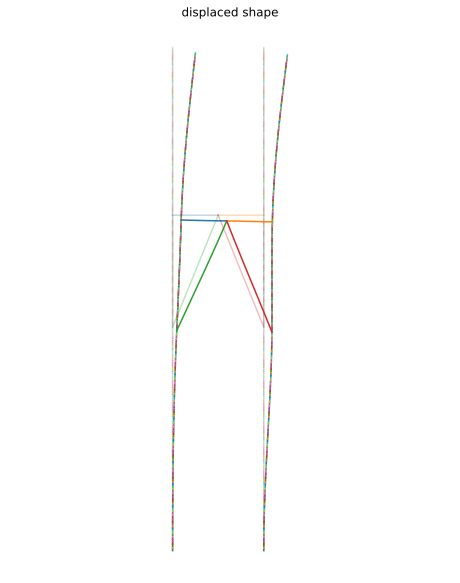

In [11]:
mm.Node.clear()
mm.Element.clear()


GN_to_kN = 1e6
GNm2_to_kNm2 = 1e6

def EI_tower(x):
    return 4000.0 * np.exp(-x / 828.0) * GNm2_to_kNm2

def EA_tower(x):
    return 13.0 * np.exp(-x / 828.0) * GN_to_kN

EI_bridge = 4000.0 * GNm2_to_kNm2
EA_bridge = 13.0 * GN_to_kN


# loads
q_tower = -20.0     # distributed load on towers
q_bridge = 100.0    # distributed load on bridge

Fx_left_top = 400.0
Fx_right_top = 500.0


# geometry
tower_height = 828.0

y_left = 0.0
y_right = 150.0
y_mid = 75.0

x_base = 0.0
x_low = 368.0
x_bridge = 552.0
x_top = 828.0

def tower_plot_z(x):
    return tower_height - x


# discretization parameter
n = 100


# required nodes
left_base = mm.Node(y_left, tower_plot_z(x_base))
left_low_node = mm.Node(y_left, tower_plot_z(x_low))
left_bridge_node = mm.Node(y_left, tower_plot_z(x_bridge))
left_top = mm.Node(y_left, tower_plot_z(x_top))

right_base = mm.Node(y_right, tower_plot_z(x_base))
right_low_node = mm.Node(y_right, tower_plot_z(x_low))
right_bridge_node = mm.Node(y_right, tower_plot_z(x_bridge))
right_top = mm.Node(y_right, tower_plot_z(x_top))

mid_bridge_node = mm.Node(y_mid, tower_plot_z(x_bridge))

nodes = [
    left_base, left_low_node, left_bridge_node, left_top,
    right_base, right_low_node, right_bridge_node, right_top,
    mid_bridge_node
]


# elements
elems = []


def discretize_variable_member(n1, n2, x1, x2, y_const, nsub, qdist=None):
    """
    Split one member into nsub small elements.
    EI and EA are evaluated at each sub-element midpoint.
    End nodes n1 and n2 are preserved; only internal nodes are created.
    """
    member_elems = []

    x_vals = np.linspace(x1, x2, nsub + 1)

    member_nodes = [n1]
    for xi in x_vals[1:-1]:
        new_node = mm.Node(y_const, tower_plot_z(xi))
        nodes.append(new_node)
        member_nodes.append(new_node)
    member_nodes.append(n2)

    for i in range(nsub):
        xa = x_vals[i]
        xb = x_vals[i + 1]
        xmid = 0.5 * (xa + xb)

        e = mm.Element(member_nodes[i], member_nodes[i + 1])
        e.set_section({
            'EI': EI_tower(xmid),
            'EA': EA_tower(xmid)
        })

        if qdist is not None:
            e.add_distributed_load(qdist)

        member_elems.append(e)
        elems.append(e)

    return member_elems


# left tower: discretize
left_tower_segments = [
    (left_base, left_low_node, x_base, x_low),
    (left_low_node, left_bridge_node, x_low, x_bridge),
    (left_bridge_node, left_top, x_bridge, x_top),
]

left_tower_elems = []
for n1, n2, x1, x2 in left_tower_segments:
    left_tower_elems.extend(
        discretize_variable_member(
            n1, n2, x1, x2, y_left, nsub=n, qdist=[q_tower, 0.0]
        )
    )


# right tower: discretize
right_tower_segments = [
    (right_base, right_low_node, x_base, x_low),
    (right_low_node, right_bridge_node, x_low, x_bridge),
    (right_bridge_node, right_top, x_bridge, x_top),
]

right_tower_elems = []
for n1, n2, x1, x2 in right_tower_segments:
    right_tower_elems.extend(
        discretize_variable_member(
            n1, n2, x1, x2, y_right, nsub=n, qdist=[q_tower, 0.0]
        )
    )


# bridge: constant properties, no discretization
e_bridge_left = mm.Element(left_bridge_node, mid_bridge_node)
e_bridge_right = mm.Element(mid_bridge_node, right_bridge_node)

e_bridge_left.set_section({
    'EI': EI_bridge,
    'EA': EA_bridge
})
e_bridge_right.set_section({
    'EI': EI_bridge,
    'EA': EA_bridge
})

e_bridge_left.add_distributed_load([0.0, q_bridge])
e_bridge_right.add_distributed_load([0.0, q_bridge])

elems.append(e_bridge_left)
elems.append(e_bridge_right)


# diagonals: constant properties, so no discretization
e_diag_left = mm.Element(left_low_node, mid_bridge_node)
e_diag_right = mm.Element(mid_bridge_node, right_low_node)

e_diag_left.set_section({
    'EI': EI_bridge,
    'EA': EA_bridge
})
e_diag_right.set_section({
    'EI': EI_bridge,
    'EA': EA_bridge
})

elems.append(e_diag_left)
elems.append(e_diag_right)


# loads
# top horizontal point loads
left_top.add_load([Fx_left_top, 0.0, 0.0])
right_top.add_load([Fx_right_top, 0.0, 0.0])


# supports
# both tower bases fixed
con = mm.Constrainer()

for dof in [0, 1, 2]:
    con.fix_dof(left_base, dof)
    con.fix_dof(right_base, dof)


# global system
ndof = 3 * len(nodes)
global_k = np.zeros((ndof, ndof))
global_f = np.zeros(ndof)

for e in elems:
    elmat = e.stiffness()
    idofs = e.global_dofs()
    global_k[np.ix_(idofs, idofs)] += elmat

for n in nodes:
    global_f[n.dofs] += n.p


# solve
Kff, Ff = con.constrain(global_k, global_f)
u = np.linalg.solve(Kff, Ff)
u_full = con.full_disp(u)

print("Free displacement vector u:")
print(u)

print("\nSupport reactions:")
print(con.support_reactions(global_k, u, global_f))


# plot
plt.figure(figsize=(8, 10))

for e in elems:
    u_elem = u_full[e.global_dofs()]
    e.plot_displaced(u_elem, num_points=51, global_c=True, scale=10)

plt.axis('equal')
plt.grid(True)
plt.title("displaced shape")
plt.show()

In [12]:
# indices of the non-discretized bridge elements
non_discretized_bridge_elems = [
    e_bridge_left,
    e_bridge_right,
    e_diag_left,
    e_diag_right,
]

print("Element numbers (indices in elems) of the non-discretized bridge elements:")
for e in non_discretized_bridge_elems:
    print(elems.index(e))

Element numbers (indices in elems) of the non-discretized bridge elements:
600
601
602
603


In [13]:
# GROUP DISCRETIZED ELEMENTS BY MAIN MEMBER

main_element_groups = {}

def collect_vertical_segment(n_start, n_end, side="left"):
    """
    Collect all discretized tower elements between n_start and n_end.
    side = "left"  -> only elements on left tower
    side = "right" -> only elements on right tower
    """
    group = []

    zmin = min(n_start.z, n_end.z)
    zmax = max(n_start.z, n_end.z)

    # tower_nodes = {left_base, left_low_node, left_bridge_node, left_top} if side == "left" else \
    #               {right_base, right_low_node, right_bridge_node, right_top}

    for e in elems:
        n1, n2 = e.nodes

        same_tower = False
        if side == "left":
            same_tower = abs(n1.x - left_base.x) < 1e-9 and abs(n2.x - left_base.x) < 1e-9
        else:
            same_tower = abs(n1.x - right_base.x) < 1e-9 and abs(n2.x - right_base.x) < 1e-9

        if not same_tower:
            continue

        if zmin <= n1.z <= zmax and zmin <= n2.z <= zmax:
            group.append(e)

    return group


# define main members
main_element_groups["left tower: base -> low"] = collect_vertical_segment(left_base, left_low_node, side="left")
main_element_groups["left tower: low -> bridge"] = collect_vertical_segment(left_low_node, left_bridge_node, side="left")
main_element_groups["left tower: bridge -> top"] = collect_vertical_segment(left_bridge_node, left_top, side="left")

main_element_groups["right tower: base -> low"] = collect_vertical_segment(right_base, right_low_node, side="right")
main_element_groups["right tower: low -> bridge"] = collect_vertical_segment(right_low_node, right_bridge_node, side="right")
main_element_groups["right tower: bridge -> top"] = collect_vertical_segment(right_bridge_node, right_top, side="right")


# print grouped indices
print("\nDiscretized elements grouped by main element:\n")

for name, group in main_element_groups.items():
    indices = [elems.index(e) for e in group]
    print(f"{name}:")
    print(indices)
    print()


Discretized elements grouped by main element:

left tower: base -> low:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]

left tower: low -> bridge:
[100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199]

left t

In [14]:
# nodal displacement
node_table = []

for i, n in enumerate(nodes, start=1):
    ux = u_full[n.dofs[0]]
    uy = u_full[n.dofs[1]]
    rz = u_full[n.dofs[2]]
    node_table.append([i, ux, uy, rz])

import pandas as pd
df_disp = pd.DataFrame(node_table, columns=["Node", "u_x [m]", "u_y [m]", "theta_z [rad]"])
print(df_disp)

     Node   u_x [m]   u_y [m]  theta_z [rad]
0       1  0.000000  0.000000       0.000000
1       2  0.682678  0.592339      -0.004514
2       3  1.416309  0.787373      -0.003096
3       4  3.757605  0.915317      -0.011412
4       5  0.000000  0.000000       0.000000
..    ...       ...       ...            ...
598   599  3.720272  1.228132      -0.012587
599   600  3.755027  1.228274      -0.012598
600   601  3.789811  1.228384      -0.012607
601   602  3.824617  1.228463      -0.012614
602   603  3.859436  1.228510      -0.012617

[603 rows x 4 columns]


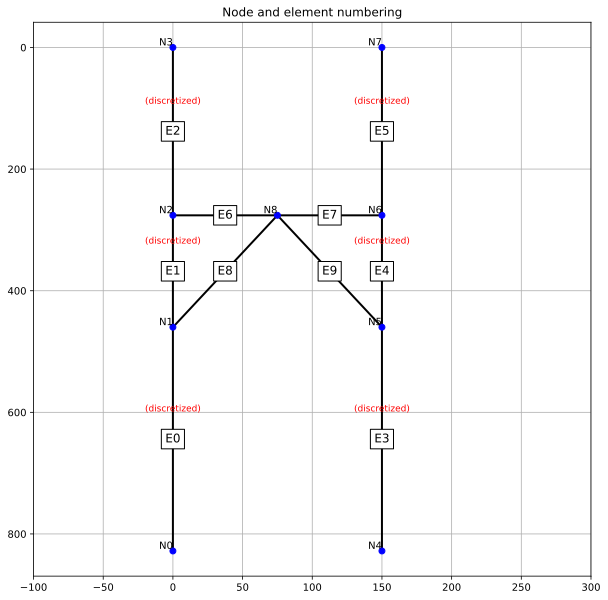

   Node    ux [m]    uy [m]  rz [rad]
0     0  0.000000  0.000000  0.000000
1     1  0.682678  0.592339 -0.004514
2     2  1.416309  0.787373 -0.003096
3     3  3.757605  0.915317 -0.011412
4     4  0.000000  0.000000  0.000000
5     5  1.348573  0.841131 -0.000569
6     6  1.422150  1.100582 -0.002223
7     7  3.894262  1.228526 -0.012619
8     8  1.414733  0.944089 -0.001822

Rounded nodal displacement table (core nodes only):
 Node       ux [m]       uy [m]      rz [rad]
    0 0.000000e+00 0.000000e+00  0.000000e+00
    1 6.826783e-01 5.923390e-01 -4.514286e-03
    2 1.416309e+00 7.873728e-01 -3.096006e-03
    3 3.757605e+00 9.153173e-01 -1.141240e-02
    4 0.000000e+00 0.000000e+00  0.000000e+00
    5 1.348573e+00 8.411307e-01 -5.685437e-04
    6 1.422150e+00 1.100582e+00 -2.223245e-03
    7 3.894262e+00 1.228526e+00 -1.261873e-02
    8 1.414733e+00 9.440894e-01 -1.821874e-03


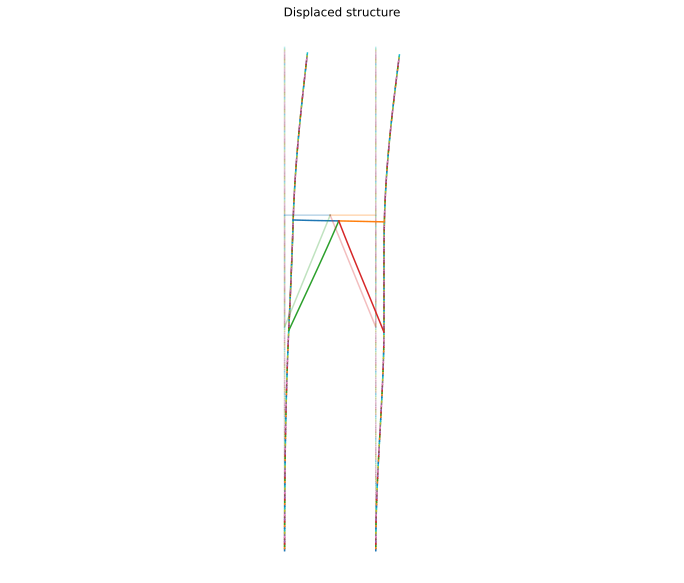

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# plot nodes and elements
plt.figure(figsize=(10, 10))
discretized_elements = set()
for group in main_element_groups.values():
    discretized_elements.update(group)

main_members = [
    ("left tower: base -> low", left_base, left_low_node),
    ("left tower: low -> bridge", left_low_node, left_bridge_node),
    ("left tower: bridge -> top", left_bridge_node, left_top),
    ("right tower: base -> low", right_base, right_low_node),
    ("right tower: low -> bridge", right_low_node, right_bridge_node),
    ("right tower: bridge -> top", right_bridge_node, right_top),
]

elem_counter = 0

for name, n1, n2 in main_members:
    plt.plot([n1.x, n2.x], [n1.z, n2.z], 'k-', linewidth=2)

    xm = 0.5 * (n1.x + n2.x)
    zm = 0.5 * (n1.z + n2.z)

    plt.text(
        xm, zm, f"E{elem_counter}",
        fontsize=12, ha='center', va='center',
        bbox=dict(facecolor='white', edgecolor='black')
    )

    elem_counter += 1

ymin, ymax = plt.ylim()
offset = 0.05 * (ymax - ymin)

for name, n1, n2 in main_members:
    xm = 0.5 * (n1.x + n2.x)
    zm = 0.5 * (n1.z + n2.z)

    plt.text(
        xm, zm - offset,
        "(discretized)",
        fontsize=9, ha='center', color='red'
    )

for e in elems:
    if e in discretized_elements:
        continue

    n1, n2 = e.nodes

    plt.plot([n1.x, n2.x], [n1.z, n2.z], 'k-', linewidth=2)

    xm = 0.5 * (n1.x + n2.x)
    zm = 0.5 * (n1.z + n2.z)

    plt.text(
        xm, zm, f"E{elem_counter}",
        fontsize=12, ha='center', va='center',
        bbox=dict(facecolor='white', edgecolor='black')
    )

    elem_counter += 1

main_nodes = []

def add_node_once(node_list, node):
    if node not in node_list:
        node_list.append(node)

for node in [
    left_base, left_low_node, left_bridge_node, left_top,
    right_base, right_low_node, right_bridge_node, right_top
]:
    add_node_once(main_nodes, node)

for e in elems:
    if e in discretized_elements:
        continue
    for node in e.nodes:
        add_node_once(main_nodes, node)

for i, node in enumerate(main_nodes):
    plt.plot(node.x, node.z, 'bo')
    plt.text(node.x, node.z, f"N{i}", fontsize=10, ha='right', va='bottom')

plt.xlim(-100, 300)
plt.grid(True)
plt.title("Node and element numbering")

# ---- FIX: mirror vertical axis
plt.gca().invert_yaxis()

plt.savefig("nodes_elements_defining.png", facecolor="white", bbox_inches="tight")
plt.show()


# table nodal displacements (core nodes only)
core_nodes = [
    left_base, left_low_node, left_bridge_node, left_top,
    right_base, right_low_node, right_bridge_node, right_top,
    mid_bridge_node
]

node_rows = []

for i, n in enumerate(core_nodes):
    node_rows.append({
        "Node": i,
        "ux [m]": u_full[n.dofs[0]],
        "uy [m]": u_full[n.dofs[1]],
        "rz [rad]": u_full[n.dofs[2]],
    })

df_nodes = pd.DataFrame(node_rows)
print(df_nodes)

# optional: nicer formatting
df_nodes_round = df_nodes.copy()
df_nodes_round["ux [m]"] = df_nodes_round["ux [m]"].map(lambda x: f"{x:.6e}")
df_nodes_round["uy [m]"] = df_nodes_round["uy [m]"].map(lambda x: f"{x:.6e}")
df_nodes_round["rz [rad]"] = df_nodes_round["rz [rad]"].map(lambda x: f"{x:.6e}")

print("\nRounded nodal displacement table (core nodes only):")
print(df_nodes_round.to_string(index=False))

# displaced structure
plt.figure(figsize=(12, 10))

for e in elems:
    u_elem = u_full[e.global_dofs()]
    e.plot_displaced(u_elem, num_points=51, global_c=True, scale=10)

plt.axis('equal')
plt.grid(True)
plt.title("Displaced structure")
plt.show()

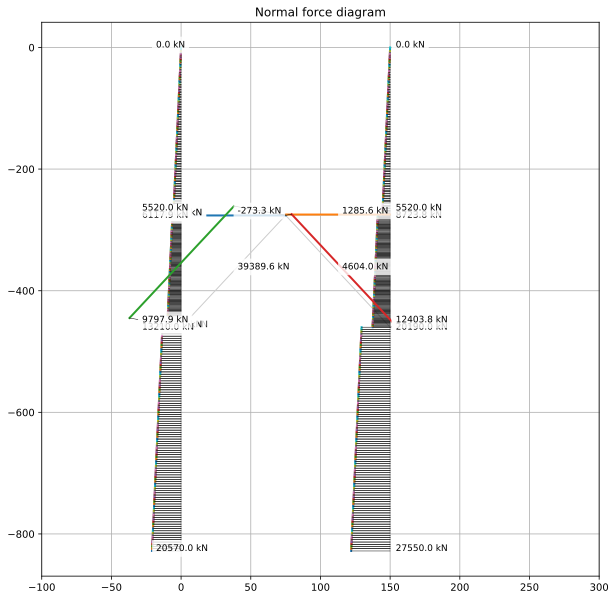


--- Normal force values shown in the plot ---

Bridge members:
bridge left    :  -273.26 kN
bridge right   :  1285.63 kN
diag left      : 39389.57 kN
diag right     :  4604.02 kN

Tower segments (bottom / top):
left tower: base -> low       : bottom = 20570.02 kN | top = 13210.02 kN
left tower: low -> bridge     : bottom =  9797.91 kN | top =  6117.91 kN
left tower: bridge -> top     : bottom =  5520.00 kN | top =     0.00 kN
right tower: base -> low      : bottom = 27549.98 kN | top = 20189.98 kN
right tower: low -> bridge    : bottom = 12403.82 kN | top =  8723.82 kN
right tower: bridge -> top    : bottom =  5520.00 kN | top =     0.00 kN

Connection points:
left low connection (from below)    : 13210.02 kN
left low connection (from above)    :  9797.91 kN
left bridge connection (from below) :  6117.91 kN
left bridge connection (from above) :  5520.00 kN
right low connection (from below)   : 20189.98 kN
right low connection (from above)   : 12403.82 kN
right bridge connection (from 

In [16]:
# the normal force diagram

def get_node_xy(node):
    if hasattr(node, "coords"):
        return node.coords[0], -node.coords[1]
    elif hasattr(node, "xy"):
        return node.xy[0], -node.xy[1]
    elif hasattr(node, "x") and hasattr(node, "z"):
        return node.x, -node.z
    elif hasattr(node, "x") and hasattr(node, "y"):
        return node.x, -node.y
    else:
        print("Node attributes:", dir(node))
        raise AttributeError("Could not find coordinate attributes for Node.")


def get_element_EA(e):
    if hasattr(e, "EA"):
        return e.EA
    elif hasattr(e, "section"):
        return e.section["EA"]
    elif hasattr(e, "properties") and "EA" in e.properties:
        return e.properties["EA"]
    elif hasattr(e, "sec") and "EA" in e.sec:
        return e.sec["EA"]
    else:
        print("Element attributes:", dir(e))
        raise AttributeError("Could not find EA on Element.")


def get_element_geometry(e):
    n1 = e.nodes[0]
    n2 = e.nodes[1]

    x1, y1 = get_node_xy(n1)
    x2, y2 = get_node_xy(n2)

    dx = x2 - x1
    dy = y2 - y1
    L = np.hypot(dx, dy)

    c = dx / L
    s = dy / L

    return x1, y1, x2, y2, L, c, s

def element_axial_force_end_values(e, u_full, qx=0.0):
    """
    Returns axial force at start and end of one frame element.

    Positive = tension
    Negative = compression

    qx = distributed axial load in LOCAL x-direction.
    For qx = 0, the axial force is constant in the element.
    """
    x1, y1, x2, y2, L, c, s = get_element_geometry(e)

    ug = u_full[e.global_dofs()]

    T = np.array([
        [ c,  s, 0, 0, 0, 0],
        [-s,  c, 0, 0, 0, 0],
        [ 0,  0, 1, 0, 0, 0],
        [ 0,  0, 0, c, s, 0],
        [ 0,  0, 0,-s, c, 0],
        [ 0,  0, 0, 0, 0, 1],
    ])

    ul = T @ ug
    EA = get_element_EA(e)

    N_def = EA / L * (ul[3] - ul[0])

    N_start = N_def - qx * L / 2.0
    N_end   = N_def + qx * L / 2.0

    return N_start, N_end


def element_axial_force_mid(e, u_full, qx=0.0):
    """
    Midpoint value = average of start and end.
    For qx=0 this equals the constant element value.
    """
    N1, N2 = element_axial_force_end_values(e, u_full, qx=qx)
    return 0.5 * (N1 + N2)


def get_element_qx(e):
    """
    Assign distributed axial load qx to each element.

    EDIT THIS FUNCTION to match your model.

    Current default:
    - bridge + diagonals: qx = 0
    - all other elements: qx = q_tower
    """
    if e in [e_bridge_left, e_bridge_right, e_diag_left, e_diag_right]:
        return 0.0
    else:
        return q_tower   # <-- make sure q_tower exists in your model

force_data = []
for e in elems:
    qx = get_element_qx(e)
    N1, N2 = element_axial_force_end_values(e, u_full, qx=qx)
    force_data.append((e, qx, N1, N2))

Nmax = max(max(abs(N1), abs(N2)) for _, _, N1, N2 in force_data)
scaleN = 40.0 / Nmax if Nmax > 0 else 1.0

plt.figure(figsize=(10, 10))

for e in elems:
    x1, y1, x2, y2, L, c, s = get_element_geometry(e)
    plt.plot([x1, x2], [y1, y2], color='0.8', lw=1)

for e, qx, N1, N2 in force_data:
    x1, y1, x2, y2, L, c, s = get_element_geometry(e)

    nx = -s
    ny =  c

    off1 = scaleN * N1
    off2 = scaleN * N2

    X1 = x1 + off1 * nx
    Y1 = y1 + off1 * ny
    X2 = x2 + off2 * nx
    Y2 = y2 + off2 * ny

    plt.plot([X1, X2], [Y1, Y2], lw=2)
    plt.plot([x1, X1], [y1, Y1], 'k-', lw=0.5)
    plt.plot([x2, X2], [y2, Y2], 'k-', lw=0.5)

def label_element_mid_value(e, qx=0.0, text_dx=3, text_dy=3):
    Nmid = element_axial_force_mid(e, u_full, qx=qx)
    x1, y1, x2, y2, L, c, s = get_element_geometry(e)
    xm = 0.5 * (x1 + x2)
    ym = 0.5 * (y1 + y2)

    plt.text(
        xm + text_dx,
        ym + text_dy,
        f"{Nmid:.1f} kN",
        fontsize=9,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.8)
    )


def label_at_point(x, y, value, text_dx=3, text_dy=3):
    plt.text(
        x + text_dx,
        y + text_dy,
        f"{value:.1f} kN",
        fontsize=9,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.8)
    )

bridge_members = [
    e_bridge_left,
    e_bridge_right,
    e_diag_left,
    e_diag_right,
]

for e in bridge_members:
    label_element_mid_value(e, qx=0.0)

tower_groups = {
    "left tower: base -> low":    list(range(0, 100)),
    "left tower: low -> bridge":  list(range(100, 200)),
    "left tower: bridge -> top":  list(range(200, 300)),
    "right tower: base -> low":   list(range(300, 400)),
    "right tower: low -> bridge": list(range(400, 500)),
    "right tower: bridge -> top": list(range(500, 600)),
}

for name, idxs in tower_groups.items():
    e_first = elems[idxs[0]]
    e_last  = elems[idxs[-1]]

    qx_first = get_element_qx(e_first)
    qx_last  = get_element_qx(e_last)

    N1_first, N2_first = element_axial_force_end_values(e_first, u_full, qx=qx_first)
    N1_last,  N2_last  = element_axial_force_end_values(e_last,  u_full, qx=qx_last)

    # bottom point of segment = lower node of first element
    x1f, y1f, x2f, y2f, Lf, cf, sf = get_element_geometry(e_first)
    if y1f < y2f:
        xb, yb = x1f, y1f
        N_bottom = N1_first
    else:
        xb, yb = x2f, y2f
        N_bottom = N2_first

    # top point of segment = upper node of last element
    x1l, y1l, x2l, y2l, Ll, cl, sl = get_element_geometry(e_last)
    if y1l > y2l:
        xt, yt = x1l, y1l
        N_top = N1_last
    else:
        xt, yt = x2l, y2l
        N_top = N2_last

    if "left tower" in name:
        dx_bottom = -18
        dx_top = -18
    else:
        dx_bottom = 4
        dx_top = 4

    label_at_point(xb, yb, N_bottom, text_dx=dx_bottom, text_dy=0)
    label_at_point(xt, yt, N_top, text_dx=dx_top, text_dy=0)

connection_labels = []

N99_1, N99_2 = element_axial_force_end_values(elems[99], u_full, qx=get_element_qx(elems[99]))
N100_1, N100_2 = element_axial_force_end_values(elems[100], u_full, qx=get_element_qx(elems[100]))

x1, y1, x2, y2, L, c, s = get_element_geometry(elems[99])
N_left_low_from_below = N99_1 if y1 > y2 else N99_2

x1, y1, x2, y2, L, c, s = get_element_geometry(elems[100])
N_left_low_from_above = N100_1 if y1 < y2 else N100_2

connection_labels.append((left_low_node, N_left_low_from_below, -28, -4))
connection_labels.append((left_low_node, N_left_low_from_above, -28,  8))

N199_1, N199_2 = element_axial_force_end_values(elems[199], u_full, qx=get_element_qx(elems[199]))
N200_1, N200_2 = element_axial_force_end_values(elems[200], u_full, qx=get_element_qx(elems[200]))

x1, y1, x2, y2, L, c, s = get_element_geometry(elems[199])
N_left_bridge_from_below = N199_1 if y1 > y2 else N199_2

x1, y1, x2, y2, L, c, s = get_element_geometry(elems[200])
N_left_bridge_from_above = N200_1 if y1 < y2 else N200_2

connection_labels.append((left_bridge_node, N_left_bridge_from_below, -28, -4))
connection_labels.append((left_bridge_node, N_left_bridge_from_above, -28,  8))

N399_1, N399_2 = element_axial_force_end_values(elems[399], u_full, qx=get_element_qx(elems[399]))
N400_1, N400_2 = element_axial_force_end_values(elems[400], u_full, qx=get_element_qx(elems[400]))

x1, y1, x2, y2, L, c, s = get_element_geometry(elems[399])
N_right_low_from_below = N399_1 if y1 > y2 else N399_2

x1, y1, x2, y2, L, c, s = get_element_geometry(elems[400])
N_right_low_from_above = N400_1 if y1 < y2 else N400_2

connection_labels.append((right_low_node, N_right_low_from_below, 4, -4))
connection_labels.append((right_low_node, N_right_low_from_above, 4,  8))

N499_1, N499_2 = element_axial_force_end_values(elems[499], u_full, qx=get_element_qx(elems[499]))
N500_1, N500_2 = element_axial_force_end_values(elems[500], u_full, qx=get_element_qx(elems[500]))

x1, y1, x2, y2, L, c, s = get_element_geometry(elems[499])
N_right_bridge_from_below = N499_1 if y1 > y2 else N499_2

x1, y1, x2, y2, L, c, s = get_element_geometry(elems[500])
N_right_bridge_from_above = N500_1 if y1 < y2 else N500_2

connection_labels.append((right_bridge_node, N_right_bridge_from_below, 4, -4))
connection_labels.append((right_bridge_node, N_right_bridge_from_above, 4,  8))

for node, value, dx, dy in connection_labels:
    x, y = get_node_xy(node)
    label_at_point(x, y, value, text_dx=dx, text_dy=dy)

plt.xlim(-100, 300)
plt.grid(True)
plt.title("Normal force diagram")
plt.show()

print("\n--- Normal force values shown in the plot ---\n")

# 1) bridge members
print("Bridge members:")
bridge_names = ["bridge left", "bridge right", "diag left", "diag right"]

for name, e in zip(bridge_names, bridge_members):
    Nmid = element_axial_force_mid(e, u_full, qx=0.0)
    print(f"{name:15s}: {Nmid:8.2f} kN")

print()

print("Tower segments (bottom / top):")

for name, idxs in tower_groups.items():
    e_first = elems[idxs[0]]
    e_last  = elems[idxs[-1]]

    qx_first = get_element_qx(e_first)
    qx_last  = get_element_qx(e_last)

    N1_first, N2_first = element_axial_force_end_values(e_first, u_full, qx=qx_first)
    N1_last,  N2_last  = element_axial_force_end_values(e_last,  u_full, qx=qx_last)

    x1f, y1f, x2f, y2f, *_ = get_element_geometry(e_first)
    if y1f < y2f:
        N_bottom = N1_first
    else:
        N_bottom = N2_first

    x1l, y1l, x2l, y2l, *_ = get_element_geometry(e_last)
    if y1l > y2l:
        N_top = N1_last
    else:
        N_top = N2_last

    print(f"{name:30s}: bottom = {N_bottom:8.2f} kN | top = {N_top:8.2f} kN")

print()

print("Connection points:")
print(f"left low connection (from below)    : {N_left_low_from_below:8.2f} kN")
print(f"left low connection (from above)    : {N_left_low_from_above:8.2f} kN")
print(f"left bridge connection (from below) : {N_left_bridge_from_below:8.2f} kN")
print(f"left bridge connection (from above) : {N_left_bridge_from_above:8.2f} kN")
print(f"right low connection (from below)   : {N_right_low_from_below:8.2f} kN")
print(f"right low connection (from above)   : {N_right_low_from_above:8.2f} kN")
print(f"right bridge connection (from below): {N_right_bridge_from_below:8.2f} kN")
print(f"right bridge connection (from above): {N_right_bridge_from_above:8.2f} kN")

In [17]:
# reaction forces at supports
R = global_k @ u_full - global_f
left_dofs = left_base.dofs
right_dofs = right_base.dofs

print("Left support reactions:")
print(f"Rx = {R[left_dofs[0]]:.3f} kN")
print(f"Ry = {R[left_dofs[1]]:.3f} kN")
print(f"Mz = {R[left_dofs[2]]:.3f} kNm")

print("\nRight support reactions:")
print(f"Rx = {R[right_dofs[0]]:.3f} kN")
print(f"Ry = {R[right_dofs[1]]:.3f} kN")
print(f"Mz = {R[right_dofs[2]]:.3f} kNm")

Left support reactions:
Rx = 66.921 kN
Ry = -20570.017 kN
Mz = 25746.777 kNm

Right support reactions:
Rx = -966.921 kN
Ry = -27549.983 kN
Mz = 195955.744 kNm


In [18]:
# node 1 force contributions

import numpy as np
import pandas as pd

target = 1
target_dofs = list(nodes[target].dofs)

def element_equivalent_load_global(e):
    """
    Equivalent nodal load vector in global coordinates caused by the
    distributed load assigned to element e.
    """
    if not hasattr(e, "q"):
        return np.zeros(6)

    q = np.array(e.q, dtype=float)
    L = e.L

    local_element_load = np.array([
        0.5 * q[0] * L,
        0.5 * q[1] * L,
        -1.0 / 12.0 * q[1] * L * L,
        0.5 * q[0] * L,
        0.5 * q[1] * L,
        1.0 / 12.0 * q[1] * L * L
    ])

    return e.Tt @ local_element_load

print(f"Node {target} DOFs: {nodes[target].dofs}")
print()

rows = []
sum_internal = np.zeros(3)
sum_equiv_load = np.zeros(3)

for i, e in enumerate(elems):
    edofs = list(e.global_dofs())
    ke = e.stiffness()
    ue = u_full[edofs]

    fe_def = ke @ ue

    fe_load = element_equivalent_load_global(e)

    if edofs[:3] == target_dofs:
        side = "first end"
        f_def = fe_def[:3].copy()
        f_load = fe_load[:3].copy()
    elif edofs[3:6] == target_dofs:
        side = "second end"
        f_def = fe_def[3:6].copy()
        f_load = fe_load[3:6].copy()
    else:
        continue

    f_total = f_def - f_load

    print(f"Element {i} ({side})")
    print(f"  deformation part     [Fx, Fy, Mz] = {f_def}")
    print(f"  dist-load equiv part [Fx, Fy, Mz] = {f_load}")
    print(f"  total force on node  [Fx, Fy, Mz] = {f_total}")
    print()

    rows.append([
        i, side,
        f_def[0], f_def[1], f_def[2],
        f_load[0], f_load[1], f_load[2],
        f_total[0], f_total[1], f_total[2]
    ])

    sum_internal += f_def
    sum_equiv_load += f_load

print("--------------------------------------------------")
print("SUM over all connected elements at this node")
print("--------------------------------------------------")
print("Sum deformation parts:")
print("[Fx, Fy, Mz] =", sum_internal)

print("\nSum equivalent distributed-load parts:")
print("[Fx, Fy, Mz] =", sum_equiv_load)

print("\nSum total element forces on node:")
print("[Fx, Fy, Mz] =", sum_internal - sum_equiv_load)

print("\nAssembled nodal load stored in node object:")
print("[Fx, Fy, Mz] =", nodes[target].p)

print("\nCheck that assembled nodal load equals sum of element load contributions:")
print("[Fx, Fy, Mz] =", sum_equiv_load - nodes[target].p)

df_joint = pd.DataFrame(rows, columns=[
    "Element", "End",
    "Fx_def", "Fy_def", "Mz_def",
    "Fx_load", "Fy_load", "Mz_load",
    "Fx_total", "Fy_total", "Mz_total"
])

print()
print(df_joint)

Node 1 DOFs: [3, 4, 5]

Element 99 (second end)
  deformation part     [Fx, Fy, Mz] = [   -66.92140497  13246.81676563 -50373.8533741 ]
  dist-load equiv part [Fx, Fy, Mz] = [-2.25335011e-15  3.68000000e+01  0.00000000e+00]
  total force on node  [Fx, Fy, Mz] = [   -66.92140497  13210.01676563 -50373.8533741 ]

Element 100 (first end)
  deformation part     [Fx, Fy, Mz] = [ -126.73622033 -9779.51240608 -5562.54222515]
  dist-load equiv part [Fx, Fy, Mz] = [-1.12667506e-15  1.84000000e+01  0.00000000e+00]
  total force on node  [Fx, Fy, Mz] = [ -126.73622033 -9797.91240608 -5562.54222515]

Element 602 (first end)
  deformation part     [Fx, Fy, Mz] = [  193.65762478 -3412.10435955 55936.39559926]
  dist-load equiv part [Fx, Fy, Mz] = [0. 0. 0.]
  total force on node  [Fx, Fy, Mz] = [  193.65762478 -3412.10435955 55936.39559926]

--------------------------------------------------
SUM over all connected elements at this node
--------------------------------------------------
Sum deformati